# Ecuación de Van der Pol



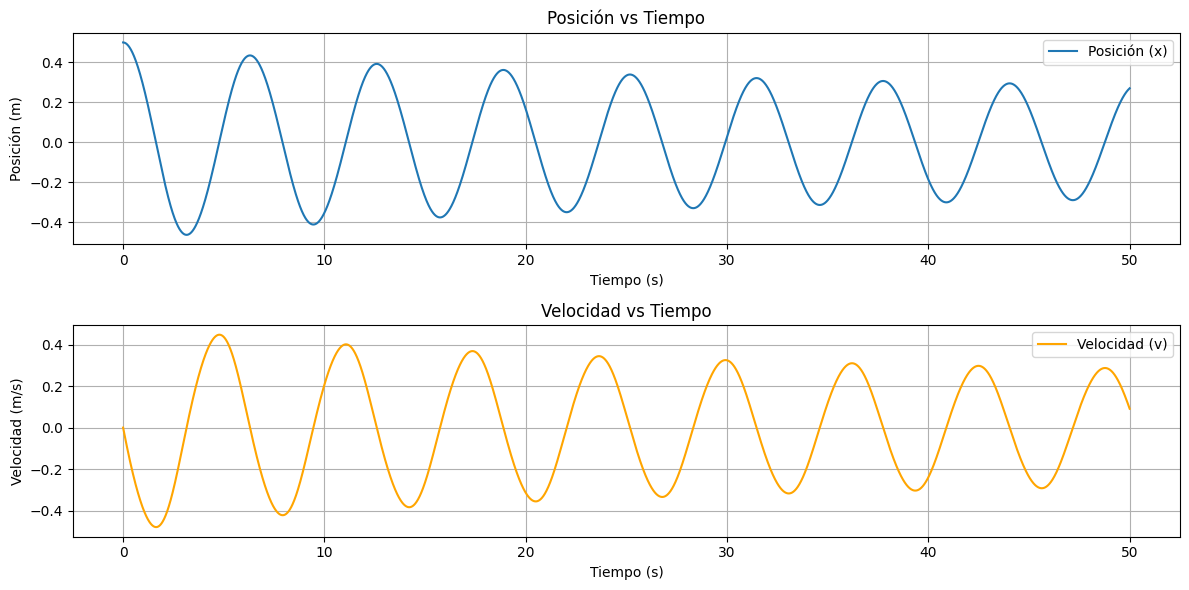

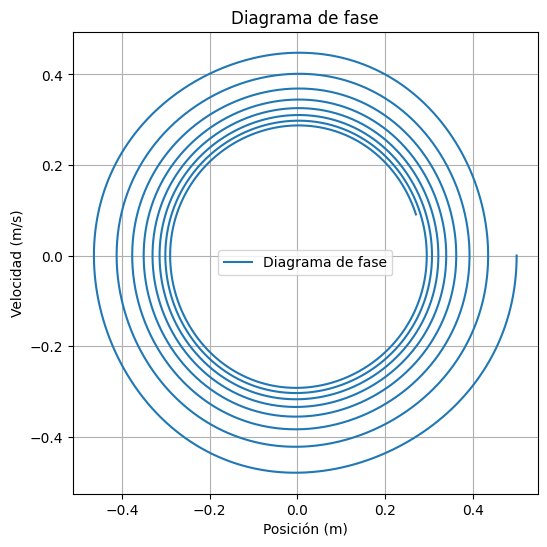

/tmp/ipykernel_4345/1356487013.py:16: RuntimeWarning: overflow encountered in scalar multiply
  dvdt = -mu * (x**2 - x0**2) * v - omega0**2 * x
/tmp/ipykernel_4345/1356487013.py:16: RuntimeWarning: overflow encountered in scalar power
  dvdt = -mu * (x**2 - x0**2) * v - omega0**2 * x
/tmp/ipykernel_4345/1356487013.py:16: RuntimeWarning: invalid value encountered in scalar subtract
  dvdt = -mu * (x**2 - x0**2) * v - omega0**2 * x


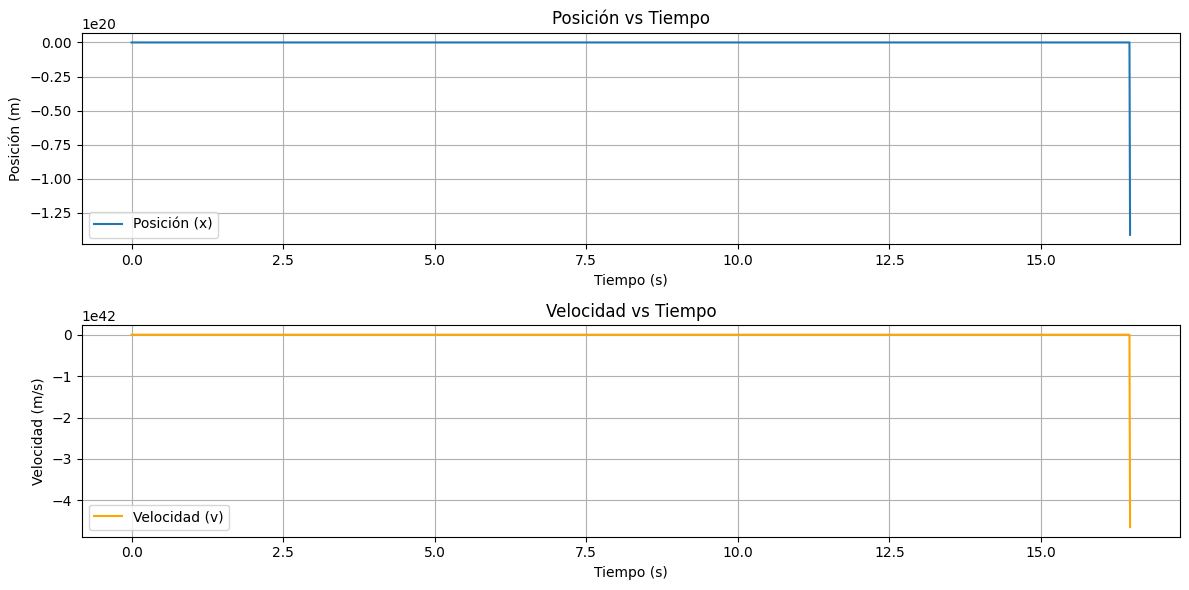

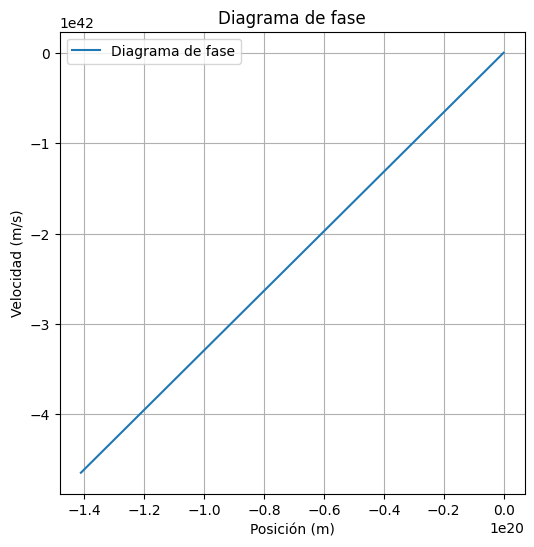

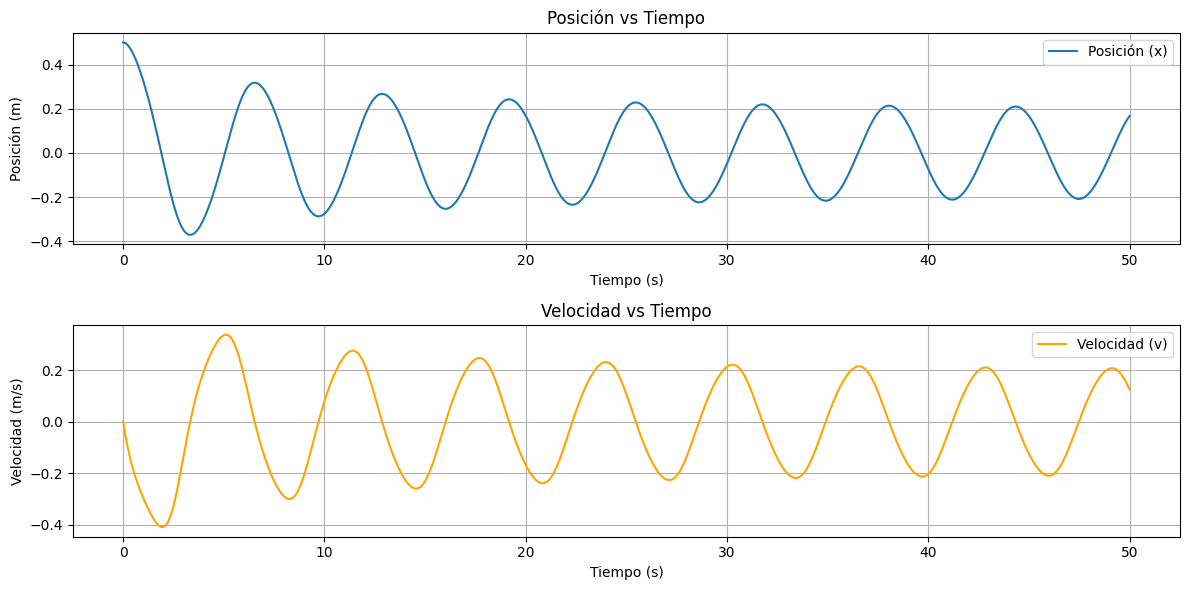

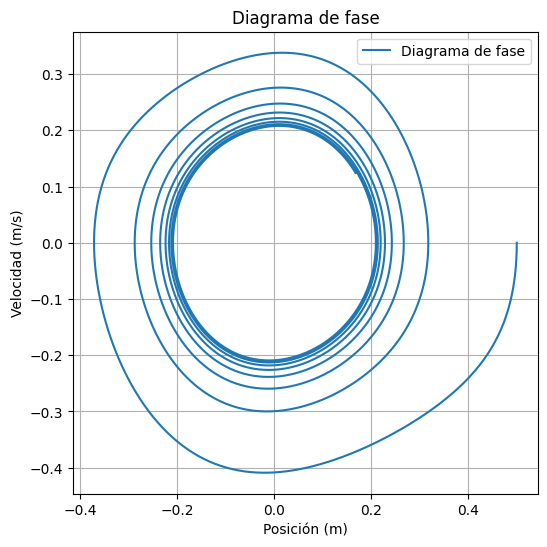

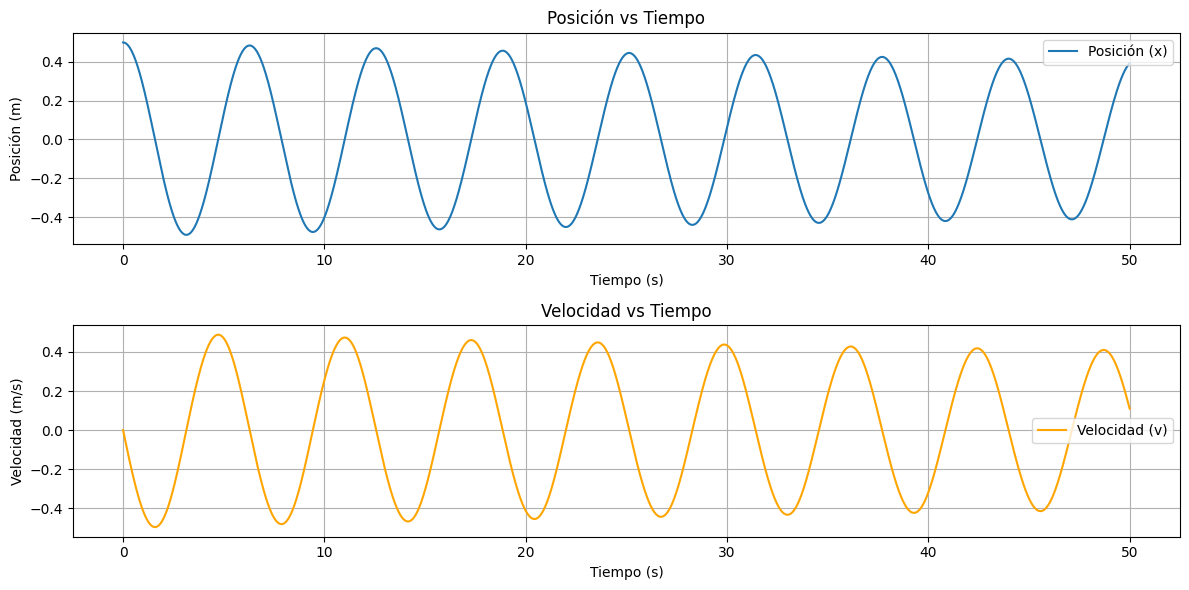

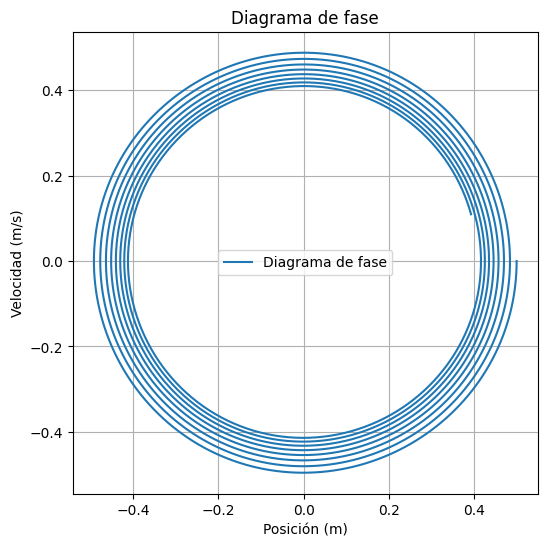

In [1]:
import fcl1109 as fc
import numpy as np
import matplotlib.pyplot as plt

# Constantes
mu = np.array([1.0,-1.0,5.0,0.2])  # Aceleración gravitacional (m/s^2)
omega0 = 1  # Frecuencia angular (rad/s)
x0 = 0.1 # Posición de equilibrio (m) 
xi = 0.5 # Posición inicial (m)
ti = vi = 0.0 # Tiempo inicial (s)

def simulate(mu, omega0, x0, xi, ti):
    def f(t, estado):
        x, v = estado
        dxdt = v
        dvdt = -mu * (x**2 - x0**2) * v - omega0**2 * x
        return np.array([dxdt, dvdt])

    # Condiciones iniciales
    estado = np.array([xi, vi])  # Posición y velocidad iniciales

    # Tiempo de simulación
    tf = 50.0
    dt = 0.01

    N_pasos = int((tf - ti) / dt)

    t_val = np.zeros(N_pasos + 1)
    x_val = np.zeros(N_pasos + 1)
    v_val = np.zeros(N_pasos + 1)

    t_val[0] = ti
    x_val[0] = estado[0]
    v_val[0] = estado[1]

    # Método de Runge-Kutta de cuarto orden
    for i in range(N_pasos):
        estado = fc.rk4(f, t_val[i], estado, dt)
        t_val[i + 1] = t_val[i] + dt
        x_val[i + 1] = estado[0]
        v_val[i + 1] = estado[1]

    # Graficar resultados
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(t_val, x_val, label='Posición (x)')
    plt.title('Posición vs Tiempo')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Posición (m)')
    plt.grid()
    plt.legend()
    plt.subplot(2, 1, 2)
    plt.plot(t_val, v_val, label='Velocidad (v)', color='orange')
    plt.title('Velocidad vs Tiempo')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Velocidad (m/s)')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Gráficar fase
    plt.figure(figsize=(6, 6))
    plt.plot(x_val, v_val, label='Diagrama de fase')
    plt.title('Diagrama de fase')
    plt.xlabel('Posición (m)')
    plt.ylabel('Velocidad (m/s)')
    plt.grid()
    plt.legend()
    plt.show()

    return 0

for mu_value in mu:
    simulate(mu_value, omega0, x0, xi, ti)

# Oscilador de Duffing

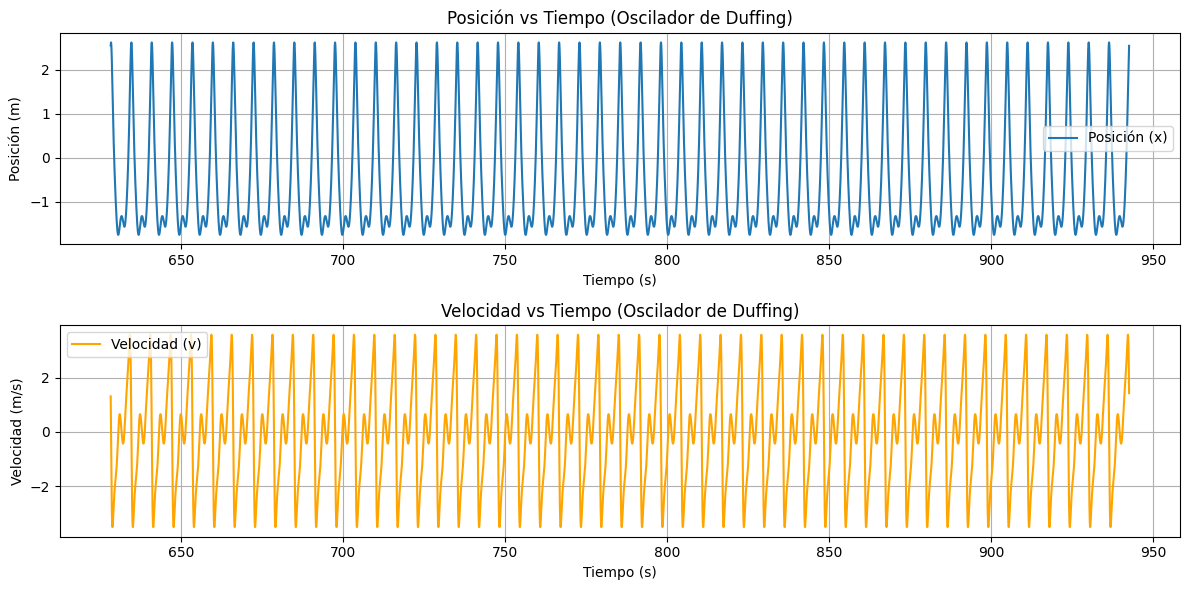

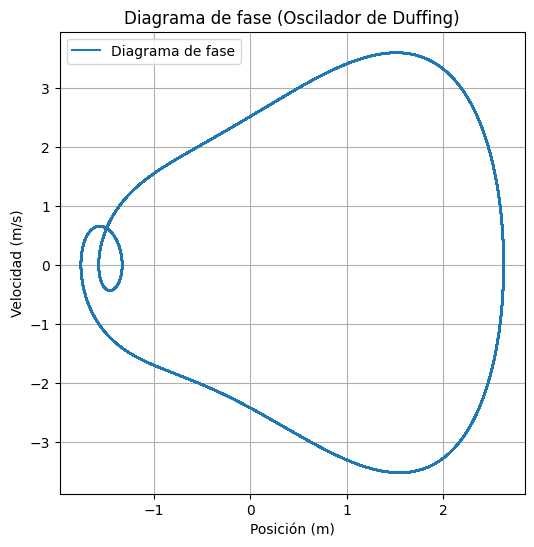

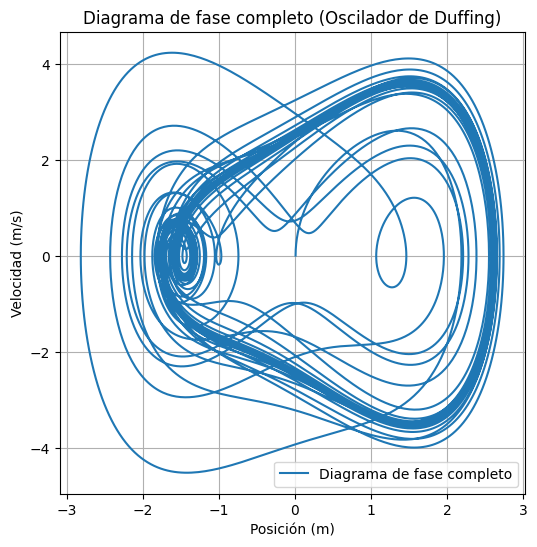

In [8]:
# Parámetros para el oscilador de Duffing
params = {
    "gamma": 0.04, #0.2, #0.04,  # Coeficiente de amortiguamiento
    "alpha": 0.0, #1.0,  # Coeficiente lineal
    "beta": 1.0, #0.2, #1.0,   # Coeficiente no lineal
    "F": 4.0, #4.0, #0.2,      # Amplitud de la fuerza de conducción
    "omega": 1.0   # Frecuencia de la fuerza de conducción
}

def rk4_step(f, t, y, h, params):
    k1 = f(t, y, params)
    k2 = f(t + h/2, y + h/2 * k1, params)
    k3 = f(t + h/2, y + h/2 * k2, params)
    k4 = f(t + h, y + h * k3, params)
    return y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

def duffing(t, y, p):
    x, v = y
    dxdt = v
    dvdt = -2*p["gamma"]*v - p["alpha"]*x - p["beta"]*x**3 + p["F"]*np.cos(p["omega"]*t)
    return np.array([dxdt, dvdt])

def simulate_duffing(f, y0, params, t_max, h):
    t_values = np.arange(0, t_max, h)
    y_values = np.zeros((len(t_values), len(y0)))
    y_values[0] = y0

    for i in range(1, len(t_values)):
        y_values[i] = rk4_step(f, t_values[i-1], y_values[i-1], h, params)

    return t_values, y_values

# Condiciones iniciales para el oscilador de Duffing
y0 = [0.009, 0.01]  # Posición inicial y velocidad inicial
t_max = 50.0    # Tiempo total de simulación
h = 0.01         # Paso de tiempo

# Eliminando transientes
T = 2*np.pi / params["omega"]  # Período de la fuerza de conducción
t_trans = 100*T
t_total = t_trans + 50*T

t_values, y_values = simulate_duffing(duffing, y0, params, t_total, h)

mask = t_values >= t_trans
x = y_values[mask, 0]
v = y_values[mask, 1]

# Graficamos x vs t, v vs t y el diagrama de fase
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_values[mask], x, label='Posición (x)')
plt.title('Posición vs Tiempo (Oscilador de Duffing)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Posición (m)')
plt.grid()
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(t_values[mask], v, label='Velocidad (v)', color='orange')
plt.title('Velocidad vs Tiempo (Oscilador de Duffing)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Diagrama de fase
plt.figure(figsize=(6, 6))
plt.plot(x, v, label='Diagrama de fase')
plt.title('Diagrama de fase (Oscilador de Duffing)')
plt.xlabel('Posición (m)')
plt.ylabel('Velocidad (m/s)')
plt.grid()
plt.legend()
plt.show()

# Graficar diagrama de fase sin mask
plt.figure(figsize=(6, 6))
plt.plot(y_values[:, 0], y_values[:, 1], label='Diagrama de fase completo')
plt.title('Diagrama de fase completo (Oscilador de Duffing)')
plt.xlabel('Posición (m)')
plt.ylabel('Velocidad (m/s)')
plt.grid()
plt.legend()
plt.show()